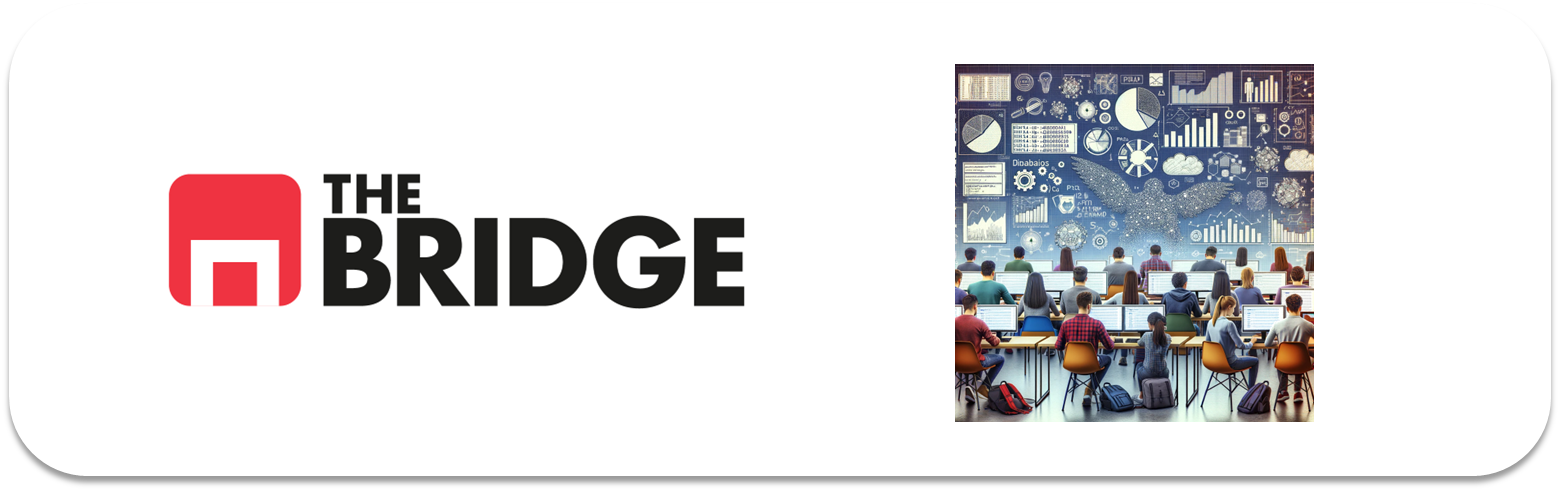

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



1. Carga el dataset del Titanic. 

In [2]:
df = pd.read_csv("./data/titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.

In [3]:
df[["embarked", "embark_town"]].head()

,embarked,embark_town
0,S,Southampton
1,C,Cherbourg
2,S,Southampton
3,S,Southampton
4,S,Southampton


In [4]:
df2 = df.copy()

In [5]:
df2 = df2.drop(columns=["alone","adult_male","class", "deck", "alive"])

In [6]:
df2 = df2.drop(columns=["embark_town"])
df2.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who
0,0,3,male,22.0,1,0,7.2500,S,man
1,1,1,female,38.0,1,0,71.2833,C,woman
2,1,3,female,26.0,0,0,7.9250,S,woman
3,1,1,female,35.0,1,0,53.1000,S,woman
4,0,3,male,35.0,0,0,8.0500,S,man


In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   who       891 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.

In [8]:
df["survived"].value_counts(normalize=True)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

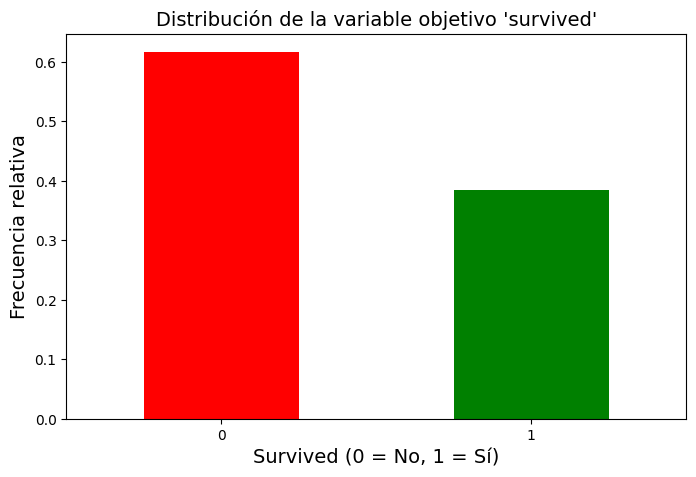

In [9]:
counts = df["survived"].value_counts(normalize=True)
plt.figure(figsize=(8,5))
counts.plot(kind = "bar", color = ["red", "green"])
plt.title("Distribución de la variable objetivo 'survived'")
plt.xlabel("Survived (0 = No, 1 = Sí)")
plt.ylabel("Frecuencia relativa")
plt.xticks(rotation=0)
plt.show();

In [10]:
numerical_cols = df2.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df2.select_dtypes(include=['object', 'category']).columns

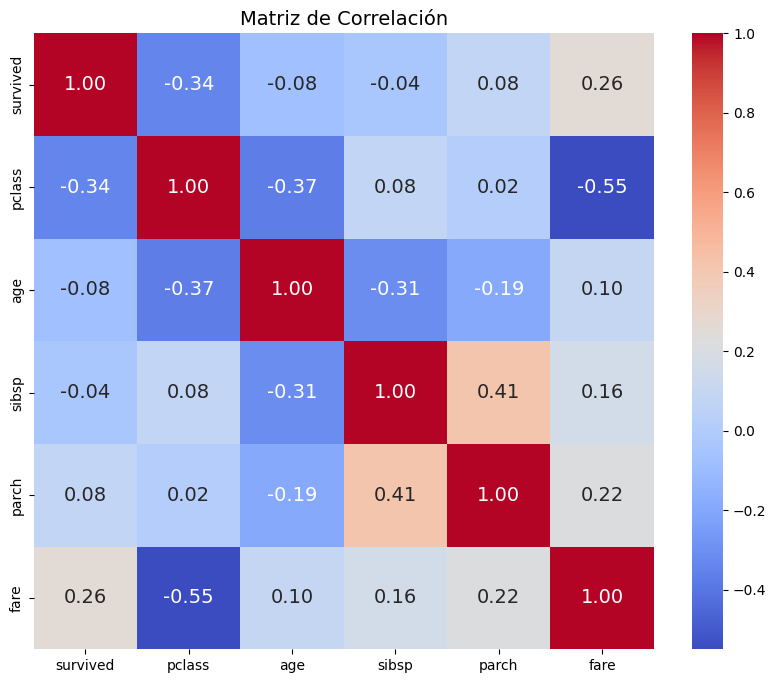

In [11]:
sns.correlation_matrix = df2[numerical_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(sns.correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show(); 

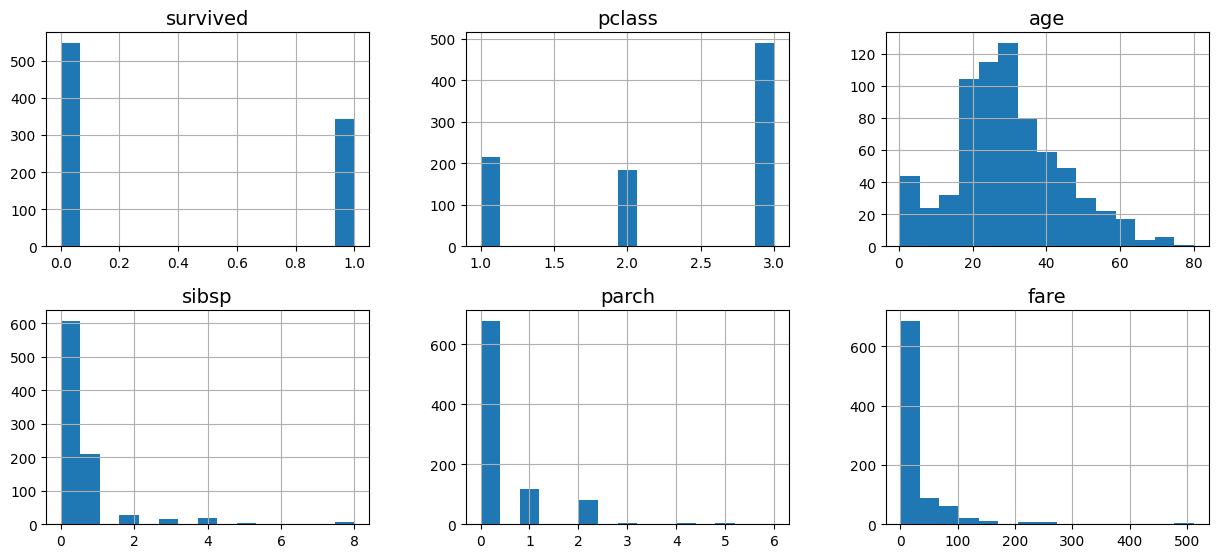

In [12]:
df2.hist(bins=15, figsize=(15,10), layout=(3,3));

In [13]:
corr_with_target = df2[numerical_cols].corr(method='pearson')['survived'].sort_values(ascending=False)
print(corr_with_target)

survived    1.000000
fare        0.257307
parch       0.081629
sibsp      -0.035322
age        -0.077221
pclass     -0.338481
Name: survived, dtype: float64


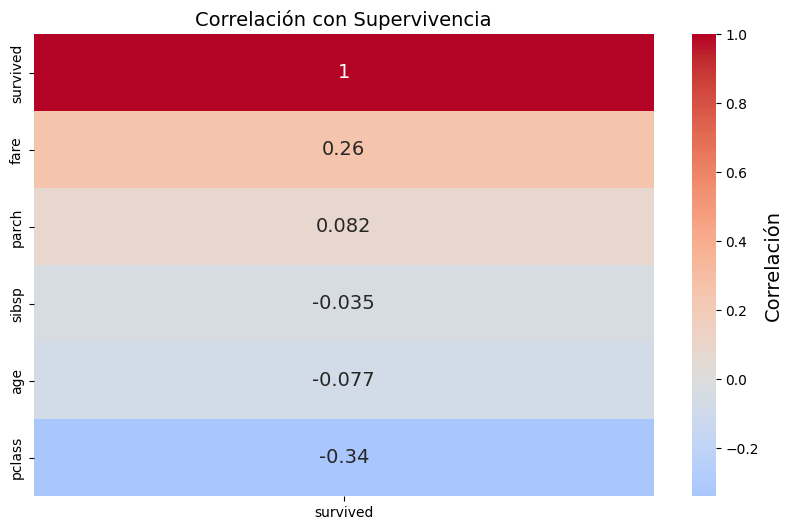

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df2[numerical_cols].corr()[['survived']].sort_values('survived', ascending=False), 
            annot=True, cmap='coolwarm', center=0, cbar_kws={'label': 'Correlación'})
plt.title('Correlación con Supervivencia')
plt.show()

4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.

In [18]:
embarked_mode = df2['embarked'].mode()[0]
df2['embarked'] = df2['embarked'].fillna(embarked_mode)


f"Moda de embarked: {embarked_mode}"
f"NaN restantes en df2: {df2['embarked'].isna().sum()}"

'NaN restantes en df2: 0'

In [19]:
X_train, X_test, y_train, y_test = train_test_split(df2.drop("survived", axis=1), 
                                                    df2["survived"], 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=df2["embarked"])

# Verificar que los repartos son similares
print("Distribución embarked en TRAIN:")
print(X_train["embarked"].value_counts(normalize=True))
print("\nDistribución embarked en TEST:")
print(X_test["embarked"].value_counts(normalize=True))

Distribución embarked en TRAIN:
embarked
S    0.724719
C    0.188202
Q    0.087079
Name: proportion, dtype: float64

Distribución embarked en TEST:
embarked
S    0.726257
C    0.189944
Q    0.083799
Name: proportion, dtype: float64


5. Construye las parejas X,y de train y test.

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 8)
(179, 8)
(712,)
(179,)


6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.

In [25]:
print("\nNan en age por categoria who:")
print(X_train.groupby("who")["age"].apply(lambda x: x.isna().sum()))


Nan en age por categoria who:
who
child      0
man      105
woman     46
Name: age, dtype: int64


In [26]:
edad_man_mean = X_train[X_train["who"] == "man"]["age"].mean()
edad_woman_mean = X_train[X_train["who"] == "woman"]["age"].mean()

print(X_train.groupby("who")["age"].mean())

who
child     5.786000
man      33.655689
woman    32.008982
Name: age, dtype: float64


In [27]:
X_train.loc[X_train["who"] == "man", "age"] = X_train.loc[X_train["who"] == "man", "age"].fillna(edad_man_mean)
X_train.loc[X_train["who"] == "woman", "age"] = X_train.loc[X_train["who"] == "woman", "age"].fillna(edad_woman_mean)

In [28]:
X_test.loc[X_test["who"] == "man", "age"] = X_test.loc[X_test["who"] == "man", "age"].fillna(edad_man_mean)
X_test.loc[X_test["who"] == "woman", "age"] = X_test.loc[X_test["who"] == "woman", "age"].fillna(edad_woman_mean)

7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.

In [44]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore")

X_train_cat_encoded = encoder.fit_transform(X_train[categorical_cols])

feature_names = encoder.get_feature_names_out(categorical_cols)
X_train_cat_encoded = pd.DataFrame(X_train_cat_encoded, columns=feature_names)
X_test_cat_encoded = encoder.transform(X_test[categorical_cols])
X_train_full = pd.concat([X_train.reset_index(drop=True).drop(columns=categorical_cols), X_train_cat_encoded.reset_index(drop=True)], axis=1)

X_test_cat_encoded = pd.DataFrame(X_test_cat_encoded, columns=feature_names)
X_test_full = pd.concat([X_test.reset_index(drop=True).drop(columns=categorical_cols), X_test_cat_encoded.reset_index(drop=True)], axis=1)

X_train_con_target = pd.concat([X_train_full, y_train.rename('survived').reset_index(drop=True)], axis=1)

correlaciones = X_train_con_target.corr()['survived'].sort_values(ascending=False)
print(correlaciones)



survived      1.000000
sex_female    0.537353
who_woman     0.516280
fare          0.263719
embarked_C    0.185234
who_child     0.110620
parch         0.075400
embarked_Q    0.029214
sibsp        -0.019424
age          -0.068907
embarked_S   -0.180542
pclass       -0.321097
sex_male     -0.537353
who_man      -0.549396
Name: survived, dtype: float64


In [40]:
umbral = 0.2

features_importantes = abs(correlaciones[correlaciones.index != "survived"]) > umbral
features_importantes = features_importantes[features_importantes].index.tolist()
print("Features importantes según el umbral de correlación:")
print(features_importantes)

Features importantes según el umbral de correlación:
['sex_female', 'who_woman', 'fare', 'pclass', 'sex_male', 'who_man']


In [45]:
X_train_final = X_train_full[features_importantes]
X_test_final = X_test_full[features_importantes]

8. Trata las variables para que funcionen lo mejor posible en el modelo.

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_escalado = scaler.fit_transform(X_train_final)
X_test_escalado = scaler.transform(X_test_final)

9. Construye un modelo de regresión logística.

In [51]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight='balanced', random_state=42)

In [52]:
log_reg.fit(X_train_escalado, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.

In [53]:
log_reg.coef_

array([[ 0.10787393,  0.15627315,  0.11587494, -0.66390876, -0.10787393,
        -0.94009407]])

11. Procesa el dataset de Test para que puedas usarlo en la evaluación

In [54]:
X_train_pred = log_reg.predict(X_train_escalado)
X_test_pred = log_reg.predict(X_test_escalado)

12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.

In [55]:
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_train, log_reg.predict(X_train_escalado))
print(acc_train)

0.7823033707865169


In [56]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, balanced_accuracy_score,\
                            roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

In [57]:
y_proba = log_reg.predict_proba(X_test_escalado)
y_pred = log_reg.predict(X_test_escalado)

In [59]:
cm = pd.DataFrame(confusion_matrix(y_test, X_test_pred), index=[f"Real {i}" for i in log_reg.classes_], 
                  columns=[f"Predicho {i}" for i in log_reg.classes_])

cm

,Predicho 0,Predicho 1
Real 0,78,25
Real 1,15,61


/Users/radc/envs/ds/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


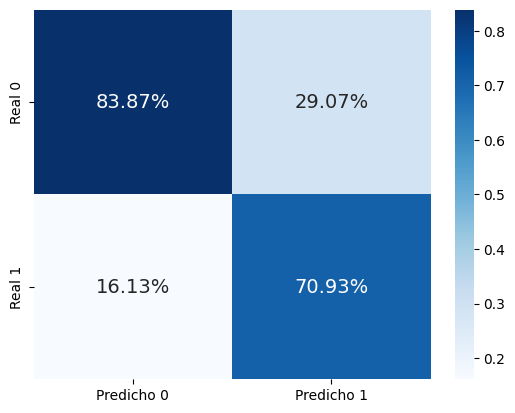

In [60]:
sns.heatmap(cm/np.sum(cm), annot=True, 
            fmt='.2%', cmap='Blues');

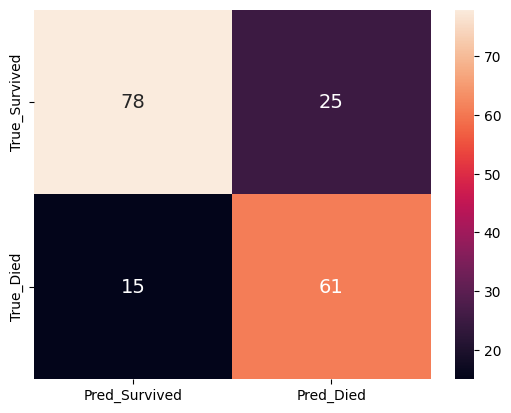

In [62]:
from sklearn.metrics import confusion_matrix

c_matrix = confusion_matrix(y_test, log_reg.predict(X_test_escalado))

c_matrix_df = pd.DataFrame(c_matrix, columns = ['Pred_Survived', 'Pred_Died'],
                          index = ['True_Survived', 'True_Died'])

sns.heatmap(c_matrix_df, annot=True, fmt='g');

In [63]:
from sklearn.metrics import classification_report
from pprint import pprint

print(classification_report(y_test, log_reg.predict(X_test_escalado)))

              precision    recall  f1-score   support

           0       0.84      0.76      0.80       103
           1       0.71      0.80      0.75        76

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.78      0.78       179



AUROC: 0.89


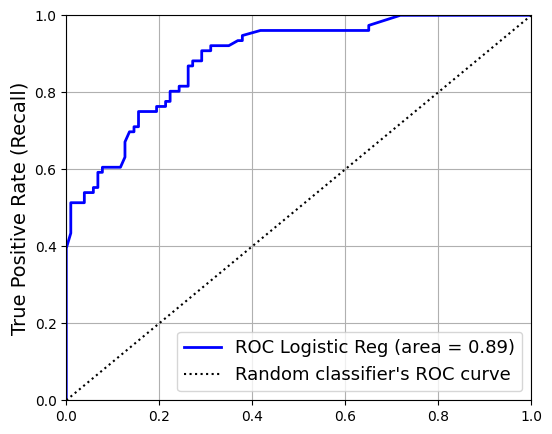

In [64]:
### Usando matplotlib
from sklearn.metrics import roc_curve, auc
scores = log_reg.predict_proba(X_test_escalado)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])
roc_auc = auc(fpr,tpr)
print("AUROC: %.2f" %(roc_auc))
plt.figure(figsize=(6, 5))  
plt.plot(fpr, tpr, linewidth=2, color= "blue", label=f"ROC Logistic Reg (area = {roc_auc:0.2f})")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
plt.show()

13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.

14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.